In [1]:
# ============================================
# Binary Classification using Deep Neural Network
# Dataset: IMDB Movie Reviews
# Task: Positive / Negative Review Classification
# ============================================

In [2]:
# 1. Import libraries
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# For same output every time
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# 2. Load IMDB dataset
# num_words=10000 means keep only top 10,000 most frequent words
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
print("First review (word indexes):", X_train[0][:20])
print("First label:", y_train[0])   # 1 = positive, 0 = negative

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples : 25000
First review (word indexes): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
First label: 1


In [4]:
# 3. Convert sequences into multi-hot encoded vectors
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, seq in enumerate(sequences):
        results[i, seq] = 1.0
    return results

X_train = vectorize_sequences(X_train)
X_test = vectorize_sequences(X_test)

y_train = np.asarray(y_train).astype("float32")
y_test = np.asarray(y_test).astype("float32")

print("Shape of X_train:", X_train.shape)
print("Shape of X_test :", X_test.shape)

Shape of X_train: (25000, 10000)
Shape of X_test : (25000, 10000)


In [5]:
# 4. Create validation set
X_val = X_train[:10000]
partial_X_train = X_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [6]:
# 5. Build Deep Neural Network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(10000,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')   # sigmoid for binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# 6. Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
# 7. Train model
history = model.fit(
    partial_X_train,
    partial_y_train,
    epochs=10,
    batch_size=512,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.7571 - loss: 0.5207 - val_accuracy: 0.8724 - val_loss: 0.3313
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.9011 - loss: 0.2718 - val_accuracy: 0.8853 - val_loss: 0.2854
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9339 - loss: 0.1867 - val_accuracy: 0.8814 - val_loss: 0.3054
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9523 - loss: 0.1397 - val_accuracy: 0.8854 - val_loss: 0.3077
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9606 - loss: 0.1094 - val_accuracy: 0.8749 - val_loss: 0.3664
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.9697 - loss: 0.0878 - val_accuracy: 0.8818 - val_loss: 0.3549
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.9843 - loss: 0.0526 - val_accuracy: 0.8804 - val_loss: 0.4042
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9898 - loss: 0.0379 - val_accuracy: 0.8805 - 

In [9]:
# 8. Evaluate model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)


Test Loss: 0.5998889207839966
Test Accuracy: 0.8514000177383423


In [10]:
# 9. Predict on test data
predictions = model.predict(X_test[:10])

print("\nSample Predictions:")
for i, pred in enumerate(predictions):
    print(f"Review {i+1}: Predicted={pred[0]:.4f}, Actual={int(y_test[i])}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

Sample Predictions:
Review 1: Predicted=0.0029, Actual=0
Review 2: Predicted=1.0000, Actual=1
Review 3: Predicted=0.8933, Actual=1
Review 4: Predicted=0.3216, Actual=0
Review 5: Predicted=0.9846, Actual=1
Review 6: Predicted=0.9864, Actual=1
Review 7: Predicted=0.9992, Actual=1
Review 8: Predicted=0.0000, Actual=0
Review 9: Predicted=0.9942, Actual=0
Review 10: Predicted=1.0000, Actual=1


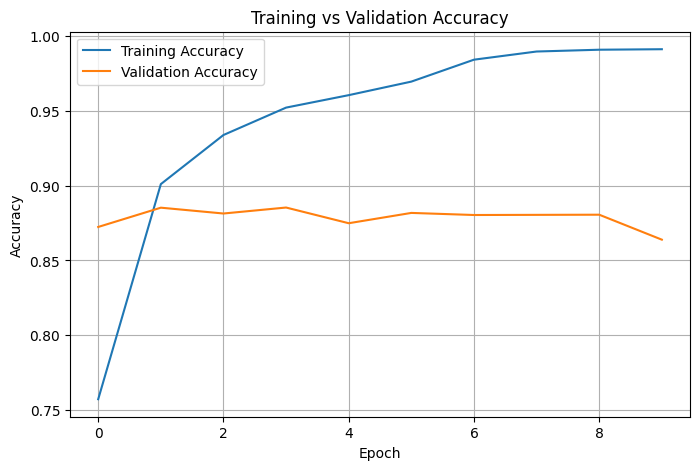

In [11]:
# 10. Plot accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

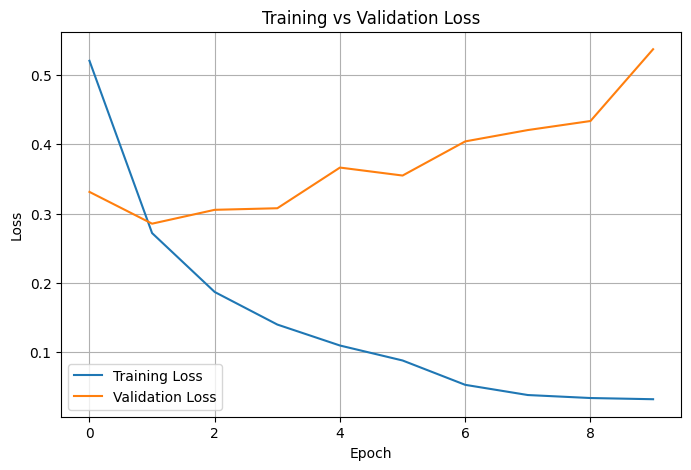

In [12]:
# 11. Plot loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()